# Transformer Sequential - Next Latent Prediction

Runs the transformer variant of the sequential model on existing AE + dataset from a prior notebook run.
Compare with LSTM results from v3-monolith-video-learner.

## Setup

In [1]:
from pathlib import Path
from datetime import datetime
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

_cwd = Path.cwd().resolve()
STUDENT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "src").is_dir() and (p / "notebooks").is_dir() and (p / "data").is_dir():
        STUDENT = p
        break
if STUDENT is None:
    raise RuntimeError("Could not find Student root")

RUNS_ROOT = STUDENT / "runs"
print("Device:", DEVICE)
print("Student:", STUDENT)

Device: mps
Student: /Users/sebastiannickels/Projects/Personal/video-to-policy/Student


### Find latest AE and Sequential runs

In [2]:
ae_runs = sorted((RUNS_ROOT / "autoencoder").glob("autoencoder_*"))
AE_RUN_DIR = ae_runs[-1]
print("AE run:", AE_RUN_DIR.name)

seq_runs = sorted((RUNS_ROOT / "sequential").glob("sequential_*"))
SEQ_SRC_DIR = None
for d in reversed(seq_runs):
    if (d / "seq_train_dataset.pt").exists():
        SEQ_SRC_DIR = d
        break
if SEQ_SRC_DIR is None:
    raise RuntimeError("No sequential run with datasets found")
print("Sequential dataset source:", SEQ_SRC_DIR.name)

stamp = datetime.now().strftime("%d%m%Y_%H%M%S")
TF_RUN_DIR = RUNS_ROOT / "sequential" / f"transformer_{stamp}"
TF_RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Transformer run dir:", TF_RUN_DIR.name)

AE run: autoencoder_26042026_220944
Sequential dataset source: sequential_26042026_220944
Transformer run dir: transformer_26042026_233305


## Load Autoencoder

In [3]:
Z_DIM = 64

class AutoEncoder(nn.Module):
    def __init__(self, z_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(25600, z_dim),
            nn.LayerNorm(z_dim),
        )
        self.decoder_fc = nn.Linear(z_dim, 25600)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84], z

    def decode(self, z):
        x_hat = self.decoder_fc(z).view(-1, 256, 10, 10)
        x_hat = self.decoder(x_hat)
        return x_hat[:, :, :84, :84]

ae_model = AutoEncoder(z_dim=Z_DIM).to(DEVICE)
ae_model.load_state_dict(torch.load(AE_RUN_DIR / "model.pth", map_location=DEVICE))
ae_model.eval()
for p in ae_model.parameters():
    p.requires_grad = False
print("AE loaded")

AE loaded


## Load Sequential Datasets

In [4]:
seq_train_data = torch.load(SEQ_SRC_DIR / "seq_train_dataset.pt", map_location="cpu")
seq_test_data = torch.load(SEQ_SRC_DIR / "seq_test_dataset.pt", map_location="cpu")

seq_train_dataset = TensorDataset(
    seq_train_data["x"], seq_train_data["lengths"], seq_train_data["episode_ids"],
)
seq_test_dataset = TensorDataset(
    seq_test_data["x"], seq_test_data["lengths"], seq_test_data["episode_ids"],
)

BATCH_SIZE = 32
seq_train_dataloader = DataLoader(seq_train_dataset, shuffle=True, batch_size=BATCH_SIZE)
seq_test_dataloader = DataLoader(seq_test_dataset, shuffle=False, batch_size=BATCH_SIZE)

print(f"Train: {len(seq_train_dataset)} chunks, Test: {len(seq_test_dataset)} chunks")

Train: 126 chunks, Test: 28 chunks


## Transformer Model

In [5]:
class LatentTransformer(nn.Module):
    def __init__(self, z_dim, hidden_dim=256, num_layers=2, n_heads=4, dropout=0.1, max_seq_len=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Linear(z_dim, hidden_dim)
        self.pos_embed = nn.Embedding(max_seq_len, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, z_dim),
        )

    def forward(self, z_seq, lengths=None):
        B, T, _ = z_seq.shape
        device = z_seq.device

        x = self.input_proj(z_seq)
        positions = torch.arange(T, device=device).unsqueeze(0)
        x = x + self.pos_embed(positions)

        causal_mask = nn.Transformer.generate_square_subsequent_mask(T, device=device, dtype=x.dtype)

        padding_mask = None
        if lengths is not None:
            seq_range = torch.arange(T, device=device).unsqueeze(0)
            bool_mask = seq_range >= lengths.unsqueeze(1)
            padding_mask = torch.zeros_like(bool_mask, dtype=x.dtype).masked_fill(bool_mask, float("-inf"))

        x = self.transformer(x, mask=causal_mask, src_key_padding_mask=padding_mask)

        if lengths is not None:
            last_idx = (lengths - 1).clamp(min=0).long()
        else:
            last_idx = torch.full((B,), T - 1, dtype=torch.long, device=device)

        h_last = x[torch.arange(B, device=device), last_idx]
        return h_last, self.head(h_last)

tf_model = LatentTransformer(
    z_dim=Z_DIM,
    hidden_dim=256,
    num_layers=2,
    n_heads=4,
    dropout=0.1,
    max_seq_len=32,
).to(DEVICE)

total_params = sum(p.numel() for p in tf_model.parameters())
print(f"LatentTransformer: {total_params:,} parameters")
print(tf_model)

LatentTransformer: 1,687,104 parameters
LatentTransformer(
  (input_proj): Linear(in_features=64, out_features=256, bias=True)
  (pos_embed): Embedding(32, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=256, out_featur

## Train

In [6]:
TF_EPOCHS = 30
TF_LR = 3e-4
TF_GRAD_CLIP = 1.0

opt = torch.optim.Adam(tf_model.parameters(), lr=TF_LR)

train_losses = []
t0 = time.time()

for epoch in range(1, TF_EPOCHS + 1):
    tf_model.train()
    ep_loss = 0.0
    n_b = 0

    for batch in seq_train_dataloader:
        x = batch[0].to(DEVICE)
        lengths = batch[1].to(DEVICE)

        z_inputs = []
        z_targets = []

        with torch.no_grad():
            for i in range(x.shape[0]):
                seq_len = int(lengths[i].item())
                if seq_len < 2:
                    continue

                x_valid = x[i:i+1, :seq_len]
                x_input = x_valid[:, :-1]
                x_target = x_valid[:, -1]

                z_list = []
                for t in range(x_input.shape[1]):
                    _, z_t = ae_model(x_input[:, t])
                    z_list.append(z_t)

                z_input = torch.stack(z_list, dim=1)
                _, z_target = ae_model(x_target)

                z_inputs.append(z_input.squeeze(0))
                z_targets.append(z_target.squeeze(0))

        if len(z_inputs) == 0:
            continue

        input_lengths = torch.tensor([z.shape[0] for z in z_inputs], dtype=torch.int64, device=DEVICE)
        max_len = int(input_lengths.max().item())

        padded_inputs = []
        for z in z_inputs:
            if z.shape[0] < max_len:
                pad = torch.zeros(max_len - z.shape[0], z.shape[1], device=DEVICE, dtype=z.dtype)
                z = torch.cat([z, pad], dim=0)
            padded_inputs.append(z)

        z_inputs_t = torch.stack(padded_inputs, dim=0)
        z_targets_t = torch.stack(z_targets, dim=0)

        h_seq, z_pred = tf_model(z_inputs_t, lengths=input_lengths)
        loss = F.mse_loss(z_pred, z_targets_t)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tf_model.parameters(), TF_GRAD_CLIP)
        opt.step()

        ep_loss += float(loss.item())
        n_b += 1

    mean_ep = ep_loss / max(n_b, 1)
    train_losses.append(mean_ep)
    print(f"[TF] epoch {epoch:03d}/{TF_EPOCHS} mean_loss {mean_ep:.6f} | {time.time() - t0:.1f}s")

[TF] epoch 001/30 mean_loss 0.931975 | 5.8s


[TF] epoch 002/30 mean_loss 0.707830 | 9.1s


[TF] epoch 003/30 mean_loss 0.586620 | 12.2s


[TF] epoch 004/30 mean_loss 0.483839 | 15.3s


[TF] epoch 005/30 mean_loss 0.409363 | 18.5s


...

[TF] epoch 026/30 mean_loss 0.066570 | 87.1s


[TF] epoch 027/30 mean_loss 0.067187 | 90.4s


[TF] epoch 028/30 mean_loss 0.064971 | 93.7s


[TF] epoch 029/30 mean_loss 0.061262 | 96.9s


[TF] epoch 030/30 mean_loss 0.062266 | 100.2s


## Eval

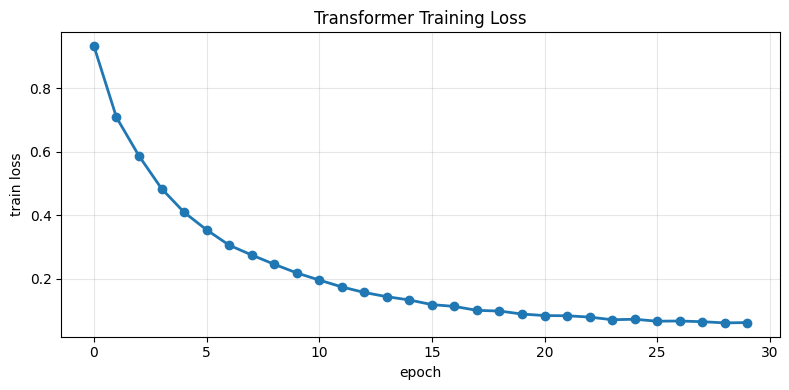

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'o-', lw=2)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("Transformer Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(TF_RUN_DIR / "loss.png", dpi=140)
plt.show()

/var/folders/1p/w0ys9r1x63942zmr4z042tc80000gp/T/ipykernel_31779/952790652.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


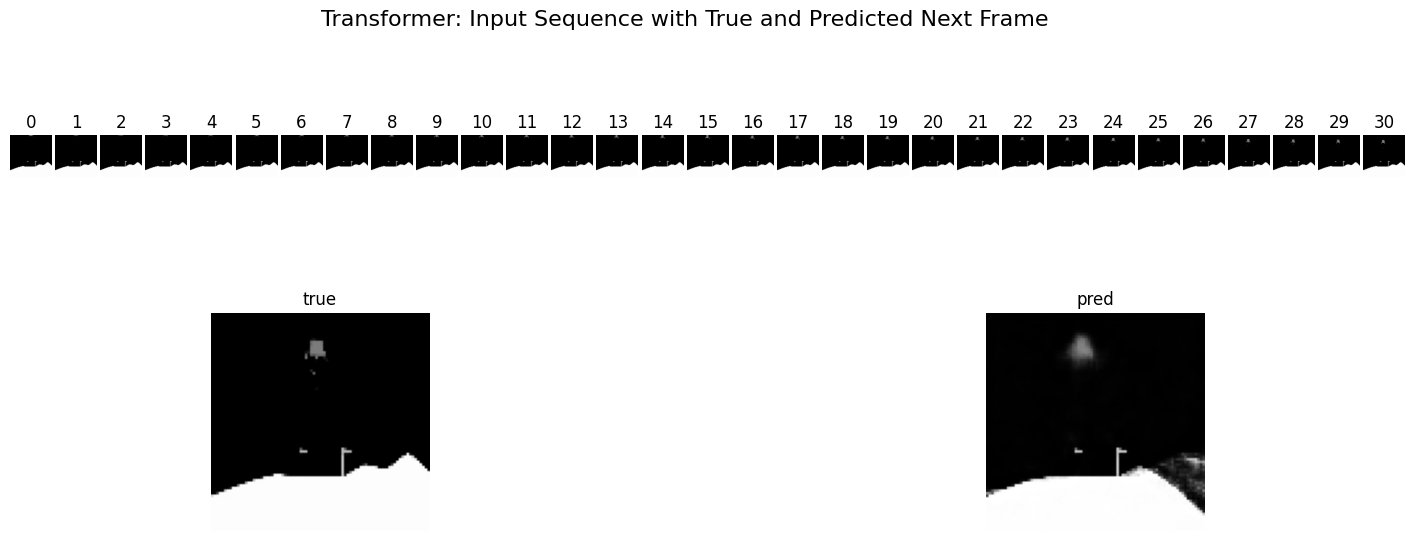

In [8]:
ae_model.eval()
tf_model.eval()

batch = next(iter(seq_test_dataloader))
x = batch[0].to(DEVICE)
lengths = batch[1].to(DEVICE)

i = torch.randint(0, x.shape[0], (1,)).item()
seq_len = int(lengths[i].item())

with torch.no_grad():
    x_valid = x[i:i+1, :seq_len]
    x_input = x_valid[:, :-1]
    x_true = x_valid[:, -1]

    z_list = []
    for t in range(x_input.shape[1]):
        _, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)
    z_input = torch.stack(z_list, dim=1)

    h_seq, z_pred = tf_model(z_input)
    x_pred = ae_model.decode(z_pred).cpu()

fig = plt.figure(figsize=(18, 6))
fig.suptitle("Transformer: Input Sequence with True and Predicted Next Frame", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)
top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(x_input[0, t, 0].cpu(), cmap="gray")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(x_true[0, 0].cpu(), cmap="gray")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(x_pred[0, 0], cmap="gray")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.tight_layout()
plt.savefig(TF_RUN_DIR / "next_frame_prediction.png", dpi=150)
plt.show()

/var/folders/1p/w0ys9r1x63942zmr4z042tc80000gp/T/ipykernel_31779/3397950619.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


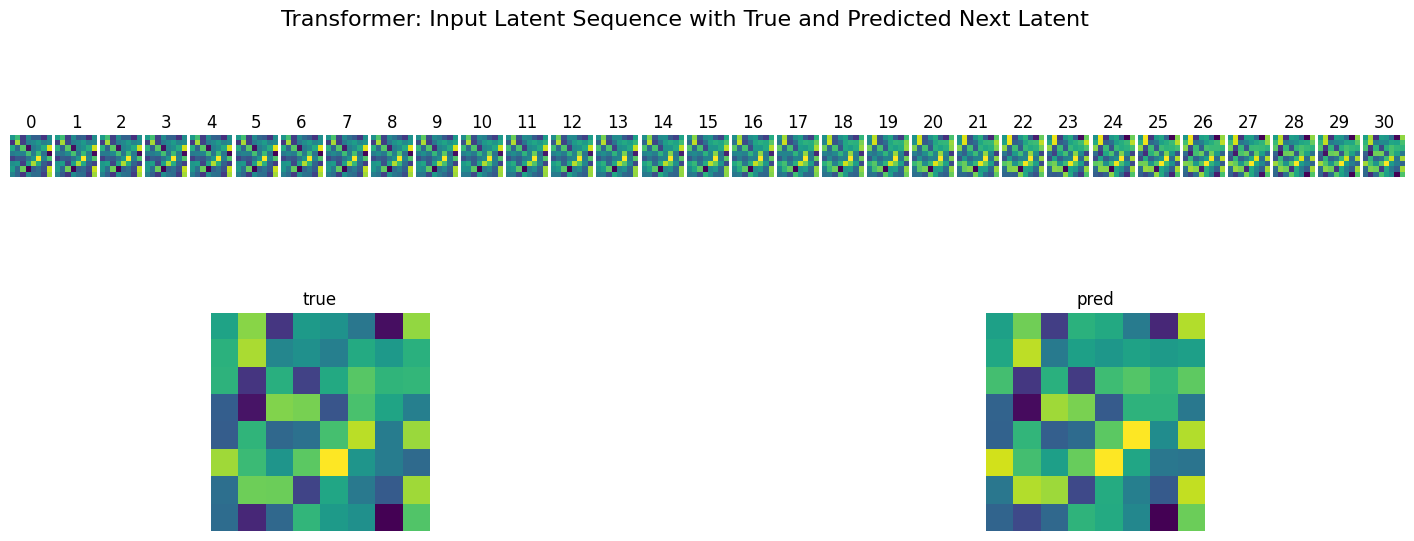

In [9]:
ae_model.eval()
tf_model.eval()

batch = next(iter(seq_test_dataloader))
x = batch[0].to(DEVICE)
lengths = batch[1].to(DEVICE)

i = 0
seq_len = int(lengths[i].item())

with torch.no_grad():
    x_valid = x[i:i+1, :seq_len]
    x_input = x_valid[:, :-1]
    x_true = x_valid[:, -1]

    z_list = []
    for t in range(x_input.shape[1]):
        _, z_t = ae_model(x_input[:, t])
        z_list.append(z_t)
    z_input = torch.stack(z_list, dim=1)

    _, z_true = ae_model(x_true)
    h_seq, z_pred = tf_model(z_input)

z_input_np = z_input.squeeze(0).cpu().numpy()
z_true_np = z_true.squeeze(0).cpu().numpy()
z_pred_np = z_pred.squeeze(0).cpu().numpy()

fig = plt.figure(figsize=(18, 6))
fig.suptitle("Transformer: Input Latent Sequence with True and Predicted Next Latent", fontsize=16)

gs = fig.add_gridspec(2, seq_len - 1, height_ratios=[1.0, 1.25], hspace=0.35, wspace=0.08)
top_axes = [fig.add_subplot(gs[0, t]) for t in range(seq_len - 1)]
bottom_gs = gs[1, :].subgridspec(1, 2, wspace=0.25)
ax_true = fig.add_subplot(bottom_gs[0, 0])
ax_pred = fig.add_subplot(bottom_gs[0, 1])

for t in range(seq_len - 1):
    top_axes[t].imshow(z_input_np[t].reshape(8, 8), cmap="viridis")
    top_axes[t].set_title(f"{t}")
    top_axes[t].axis("off")

ax_true.imshow(z_true_np.reshape(8, 8), cmap="viridis")
ax_true.set_title("true")
ax_true.axis("off")

ax_pred.imshow(z_pred_np.reshape(8, 8), cmap="viridis")
ax_pred.set_title("pred")
ax_pred.axis("off")

plt.tight_layout()
plt.savefig(TF_RUN_DIR / "next_latent_prediction.png", dpi=150)
plt.show()

## Save

In [ ]:
torch.save(tf_model.state_dict(), TF_RUN_DIR / "model.pth")
torch.save(train_losses, TF_RUN_DIR / "losses.pt")

meta = {
    "model": "transformer",
    "z_dim": Z_DIM,
    "seq_len": 32,
    "ae_run_dir": str(AE_RUN_DIR),
    "seq_dataset_dir": str(SEQ_SRC_DIR),
    "num_epochs": TF_EPOCHS,
    "learning_rate": TF_LR,
    "grad_clip": TF_GRAD_CLIP,
    "n_heads": 4,
    "hidden_dim": 256,
    "num_layers": 2,
}
torch.save(meta, TF_RUN_DIR / "meta.pt")

print("saved model ->", TF_RUN_DIR / "model.pth")
print("saved losses ->", TF_RUN_DIR / "losses.pt")
print("saved meta ->", TF_RUN_DIR / "meta.pt")

saved model -> /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/sequential/transformer_26042026_233305/model.pth
saved losses -> /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/sequential/transformer_26042026_233305/losses.pt
saved meta -> /Users/sebastiannickels/Projects/Personal/video-to-policy/Student/runs/sequential/transformer_26042026_233305/meta.pt
